In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

In [13]:
# load the dataset
df = pd.read_csv("../data/bmw_global_sales_2018_2025_cleaned.csv")
df.head(5)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Date
0,2018,January,Europe,3 Series,7822,47482.0,371404204.0,0.011,19.12,3.5,1.0,2018-01-01
1,2018,January,Europe,5 Series,10280,61685.0,634121800.0,0.019,19.12,3.5,1.0,2018-01-01
2,2018,January,Europe,X3,3105,58433.0,181434465.0,0.022,19.12,3.5,1.0,2018-01-01
3,2018,January,Europe,X5,7420,67955.0,504226100.0,0.021,19.12,3.5,1.0,2018-01-01
4,2018,January,Europe,X7,8474,92300.0,782150200.0,0.035,19.12,3.5,1.0,2018-01-01


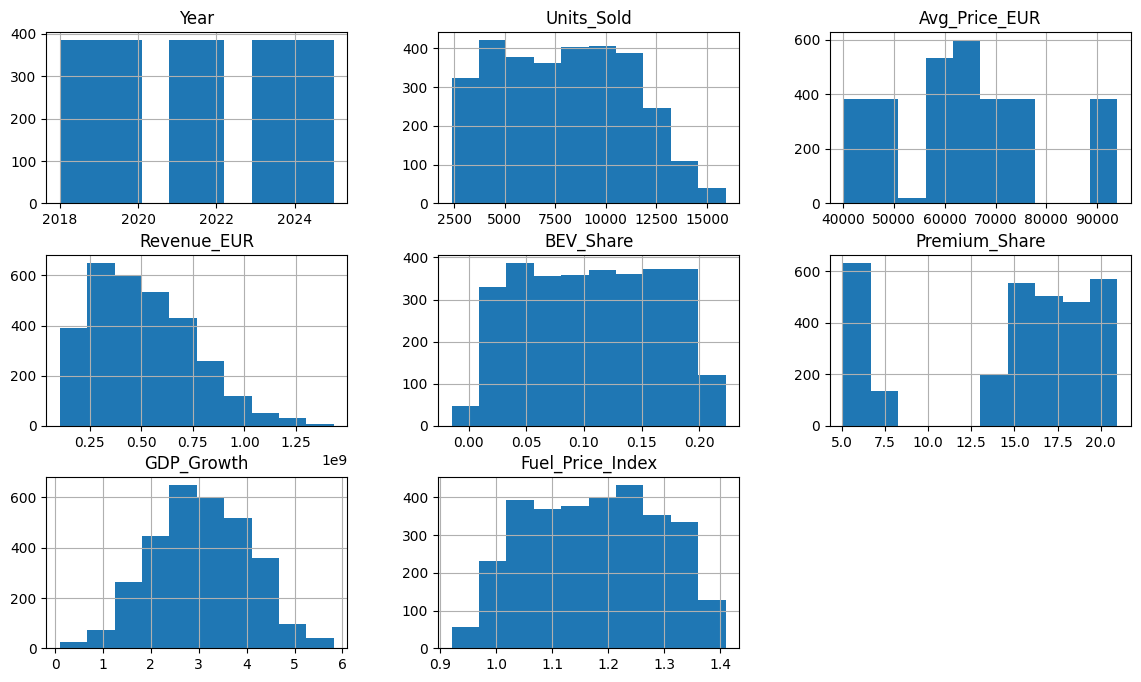

In [14]:
df.hist(figsize=(14,8))
plt.show()

In [15]:
df.head(5)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Date
0,2018,January,Europe,3 Series,7822,47482.0,371404204.0,0.011,19.12,3.5,1.0,2018-01-01
1,2018,January,Europe,5 Series,10280,61685.0,634121800.0,0.019,19.12,3.5,1.0,2018-01-01
2,2018,January,Europe,X3,3105,58433.0,181434465.0,0.022,19.12,3.5,1.0,2018-01-01
3,2018,January,Europe,X5,7420,67955.0,504226100.0,0.021,19.12,3.5,1.0,2018-01-01
4,2018,January,Europe,X7,8474,92300.0,782150200.0,0.035,19.12,3.5,1.0,2018-01-01


Total units sold each year:  Year
2018    2765193
2019    2759838
2020    3036556
2021    3036564
2022    3083306
2023    3177788
2024    3293423
2025    3362777
Name: Units_Sold, dtype: int64


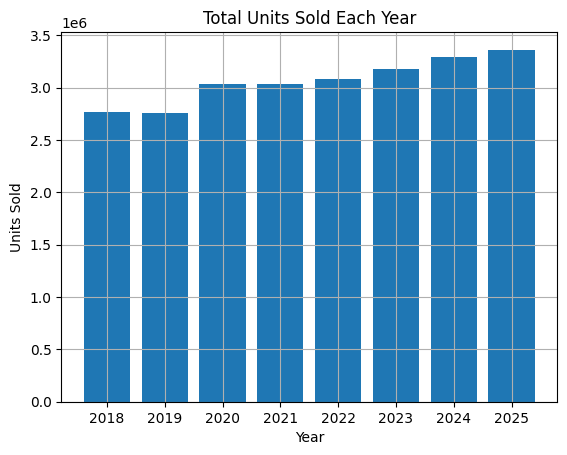

In [21]:
# Total units sold each year

print("Total units sold each year: ", df.groupby('Year')['Units_Sold'].sum())

plt.bar(df.groupby('Year')['Units_Sold'].sum().index, df.groupby('Year')['Units_Sold'].sum().values)
plt.xlabel('Year')
plt.ylabel('Units Sold')
plt.title('Total Units Sold Each Year')
plt.xticks(df.groupby('Year')['Units_Sold'].sum().index)
plt.grid()
plt.show()  


Total units sold each month:  Month
June         2300799
March        2295284
December     2239672
September    2196858
May          1970167
July         1958031
April        1952674
November     1946421
February     1923832
August       1919289
October      1916535
January      1895883
Name: Units_Sold, dtype: int64


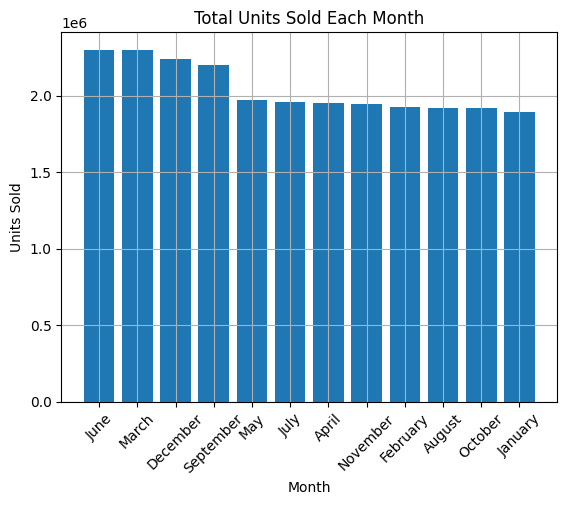

In [28]:
# data distribution over months
print("Total units sold each month: ", df.groupby('Month')['Units_Sold'].sum().sort_values(ascending=False))

plt.bar(df.groupby('Month')['Units_Sold'].sum().sort_values(ascending=False).index, df.groupby('Month')['Units_Sold'].sum().sort_values(ascending=False).values)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.title('Total Units Sold Each Month')
plt.xticks(df.groupby('Month')['Units_Sold'].sum().sort_values(ascending=False).index, rotation=45)
plt.grid()
plt.show()  

Total units sold each model:  Model
iX          3136912
i4          3125687
X7          3112074
X5          3085134
5 Series    3052524
X3          3025861
3 Series    3006048
MINI        2971205
Name: Units_Sold, dtype: int64


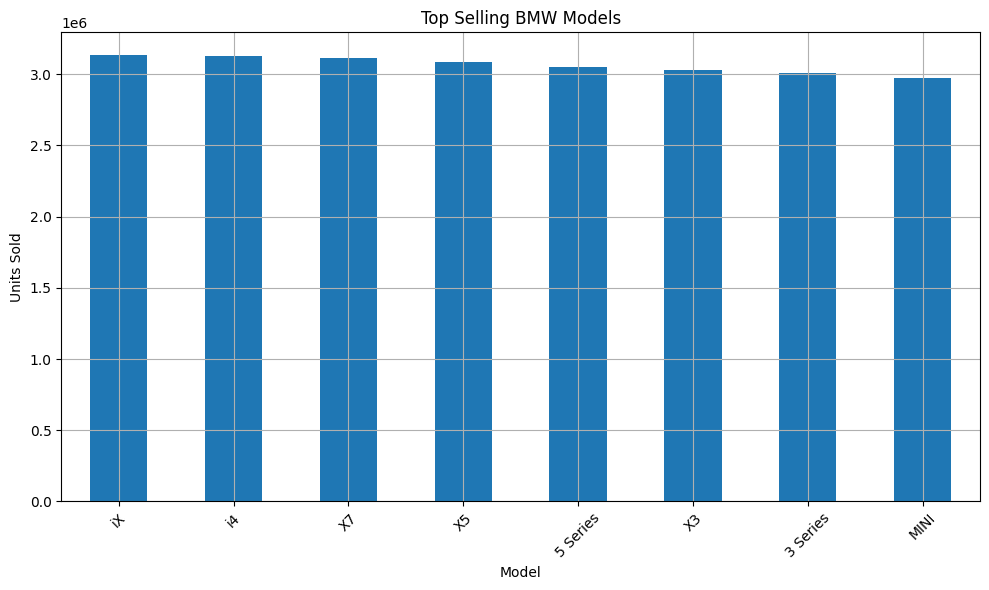

In [45]:
model_sales = df.groupby("Model")["Units_Sold"].sum().sort_values(ascending=False)
print("Total units sold each model: ", model_sales)

model_sales.head(10).plot(kind="bar", figsize=(10,6), title="Top Selling BMW Models")
plt.xlabel("Model")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.title("Top Selling BMW Models")
plt.show()


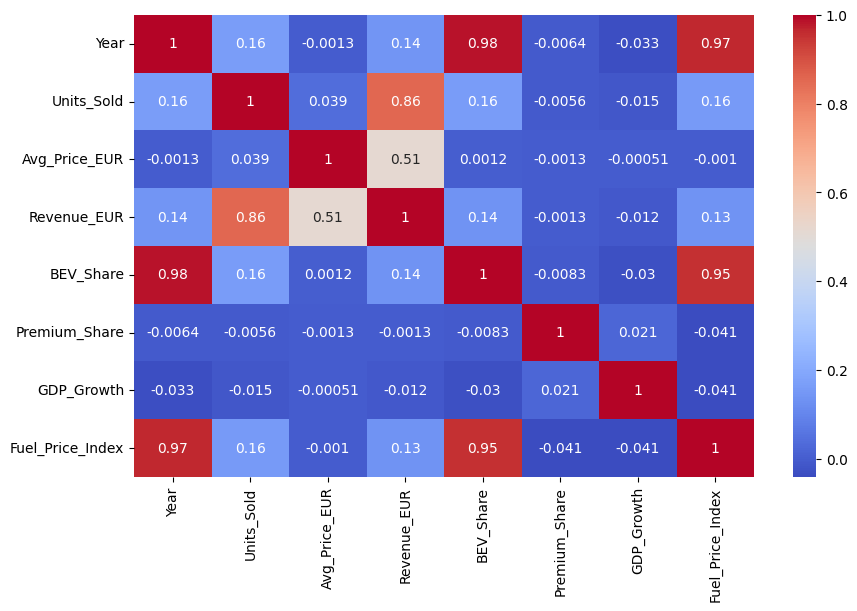

In [32]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

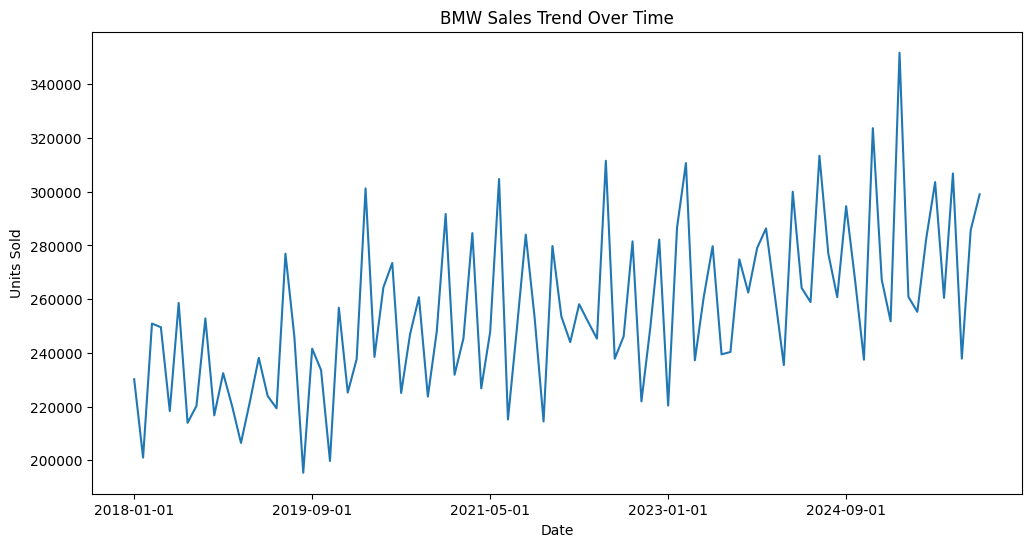

In [33]:
sales_trend = df.groupby("Date")["Units_Sold"].sum()

sales_trend.plot(figsize=(12,6), title="BMW Sales Trend Over Time")
plt.ylabel("Units Sold")
plt.show()

Total units sold by region:  Region
China          6256750
RestOfWorld    6113872
USA            6099647
Europe         6045176
Name: Units_Sold, dtype: int64 



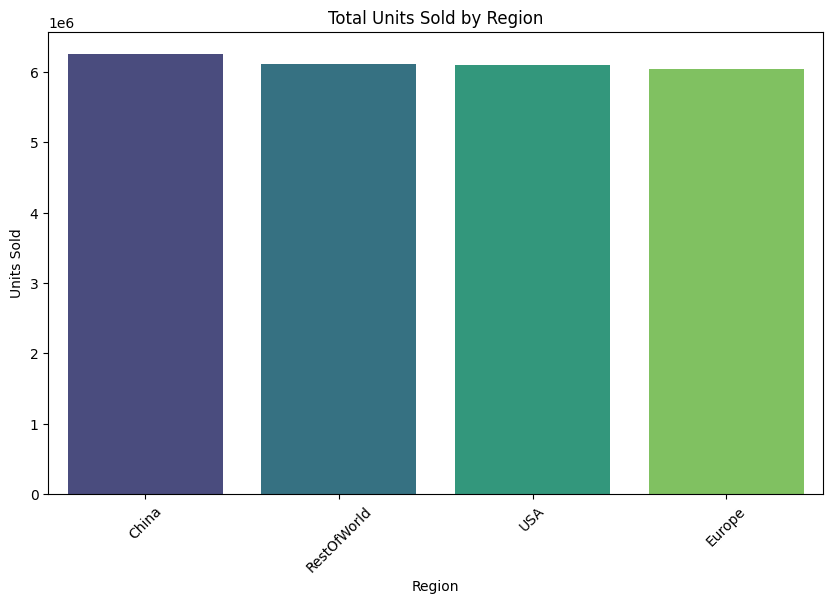

In [35]:
# Regional Sales Analysis
regional_sales = df.groupby("Region")["Units_Sold"].sum().sort_values(ascending=False)
print("Total units sold by region: ", regional_sales,'\n')

plt.figure(figsize=(10,6))
sns.barplot(x=regional_sales.index, y=regional_sales.values, palette="viridis")
plt.title("Total Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

Average BEV share over time:  Date
2018-01-01    0.016469
2018-02-01    0.023563
2018-03-01    0.021063
2018-04-01    0.019813
2018-05-01    0.021688
                ...   
2025-08-01    0.194375
2025-09-01    0.192406
2025-10-01    0.195719
2025-11-01    0.192656
2025-12-01    0.193969
Name: BEV_Share, Length: 96, dtype: float64


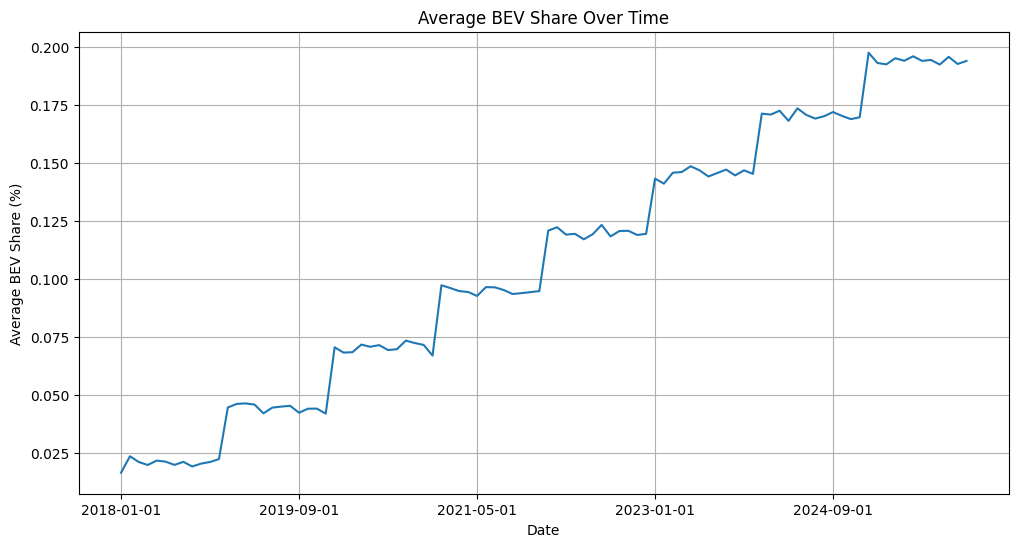

In [50]:
# EV Adoption Trend
bev_ev_trend = df.groupby('Date')['BEV_Share'].mean()
print("Average BEV share over time: ", bev_ev_trend)

bev_ev_trend.plot(figsize=(12,6), title="Average BEV Share Over Time")
plt.title("Average BEV Share Over Time")
plt.xlabel("Date")
plt.ylabel("Average BEV Share (%)")
plt.grid()
plt.show()

# Economic Impact Analysis

In [52]:
df.head(3)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Date
0,2018,January,Europe,3 Series,7822,47482.0,371404204.0,0.011,19.12,3.5,1.0,2018-01-01
1,2018,January,Europe,5 Series,10280,61685.0,634121800.0,0.019,19.12,3.5,1.0,2018-01-01
2,2018,January,Europe,X3,3105,58433.0,181434465.0,0.022,19.12,3.5,1.0,2018-01-01


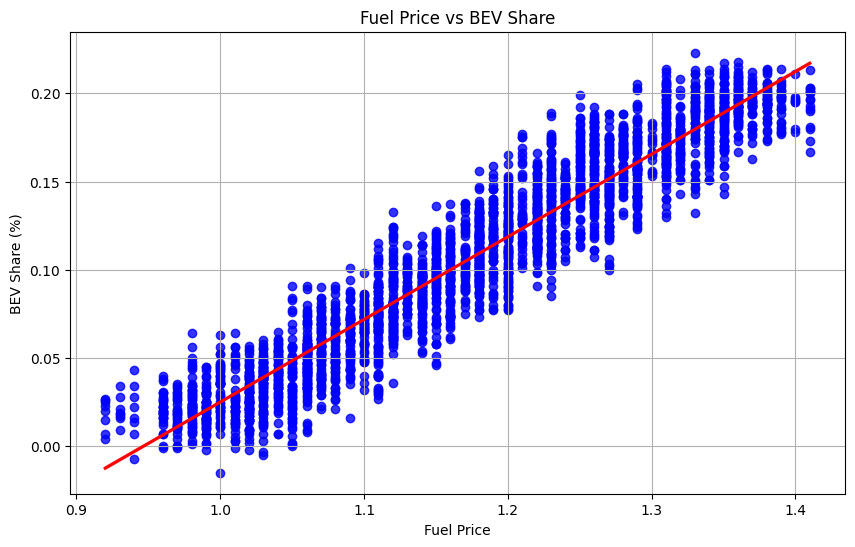

In [64]:
# Fuel price vs EV adoption
plt.figure(figsize=(10,6))

sns.regplot(
    x=df['Fuel_Price_Index'],
    y=df['BEV_Share'],
    scatter_kws={'color':'blue'},
    line_kws={'color':'red'}
)

plt.title("Fuel Price vs BEV Share")
plt.xlabel("Fuel Price")
plt.ylabel("BEV Share (%)")
plt.grid()
plt.show()


Higher fuel prices → higher EV adoption

Fuel price affects has affect on EV adoption

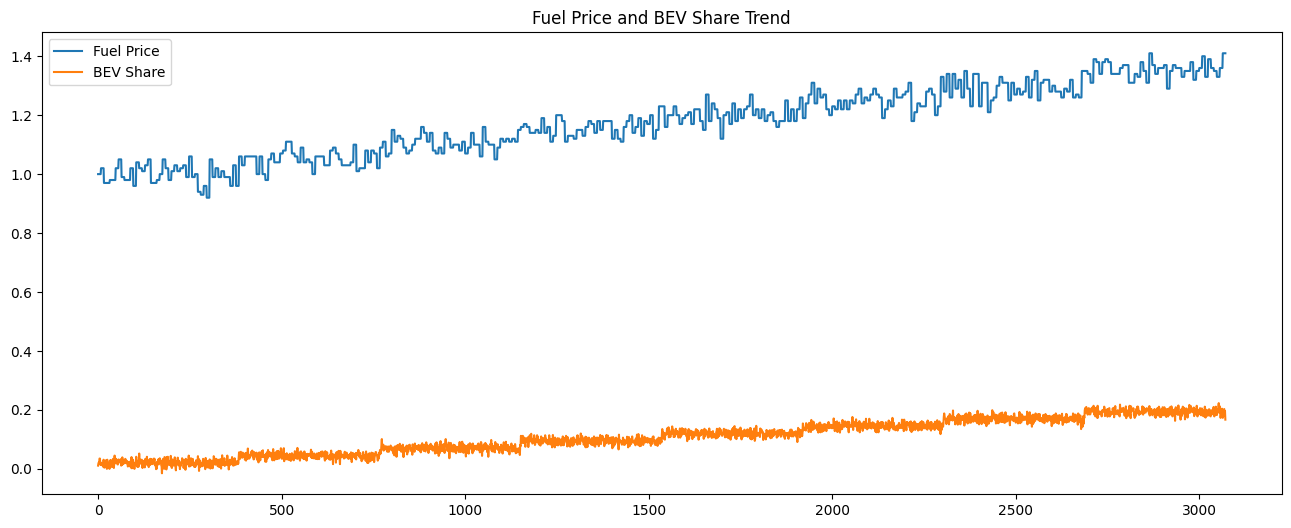

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df['Fuel_Price_Index'], label="Fuel Price")
plt.plot(df['BEV_Share'], label="BEV Share")
plt.legend()
plt.title("Fuel Price and BEV Share Trend")
plt.show()

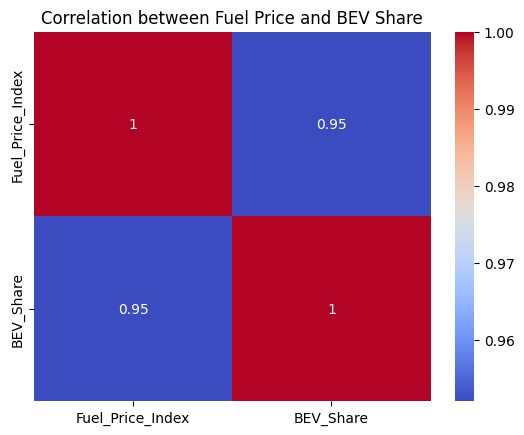

In [70]:
corr = df[['Fuel_Price_Index','BEV_Share']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Fuel Price and BEV Share")
plt.show()

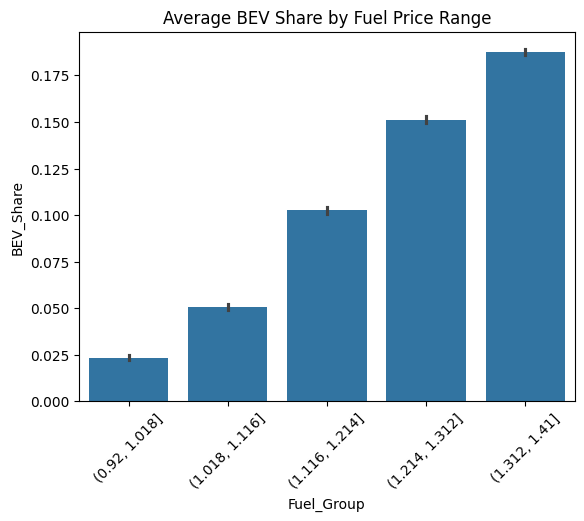

In [71]:
df['Fuel_Group'] = pd.cut(df['Fuel_Price_Index'], bins=5)

sns.barplot(x='Fuel_Group', y='BEV_Share', data=df)
plt.xticks(rotation=45)
plt.title("Average BEV Share by Fuel Price Range")
plt.show()

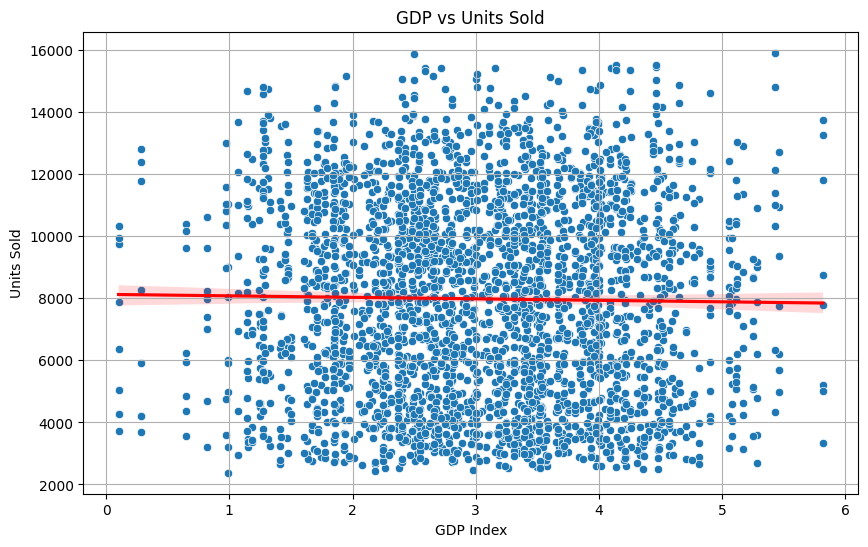

In [72]:
# GDP vs car sales

plt.figure(figsize=(10,6))
sns.scatterplot(x=df['GDP_Growth'], y=df['Units_Sold'])
sns.regplot(x=df['GDP_Growth'], y=df['Units_Sold'], scatter=False, color='red')
plt.title("GDP vs Units Sold")
plt.xlabel("GDP Index")
plt.ylabel("Units Sold")
plt.grid()
plt.show()


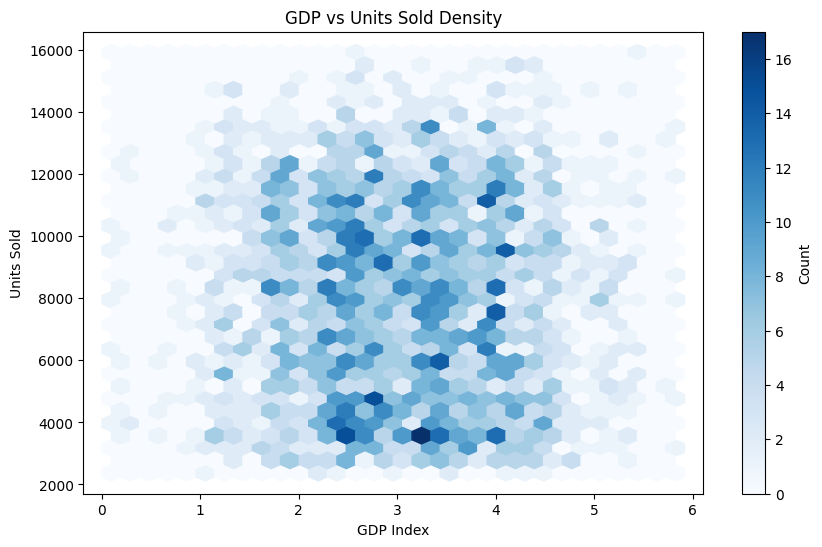

In [77]:
#Hexbin Plot
plt.figure(figsize=(10,6))
plt.hexbin(df['GDP_Growth'], df['Units_Sold'], gridsize=30, cmap='Blues')
plt.colorbar(label='Count')
plt.title("GDP vs Units Sold Density")
plt.xlabel("GDP Index")
plt.ylabel("Units Sold")
plt.show()

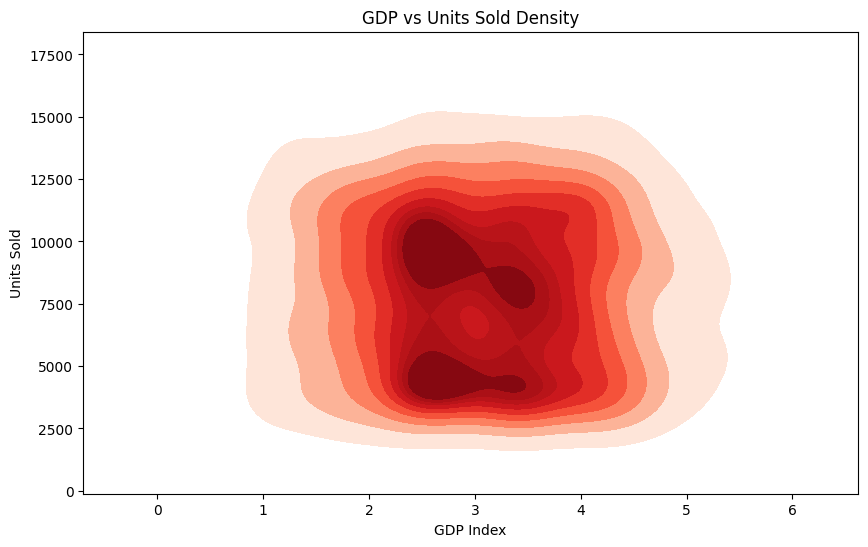

In [79]:
# Shows probability density instead of individual dots.
plt.figure(figsize=(10,6))
sns.kdeplot(x=df['GDP_Growth'], y=df['Units_Sold'], cmap="Reds", fill=True)
plt.title("GDP vs Units Sold Density")
plt.xlabel("GDP Index")
plt.ylabel("Units Sold")
plt.show()

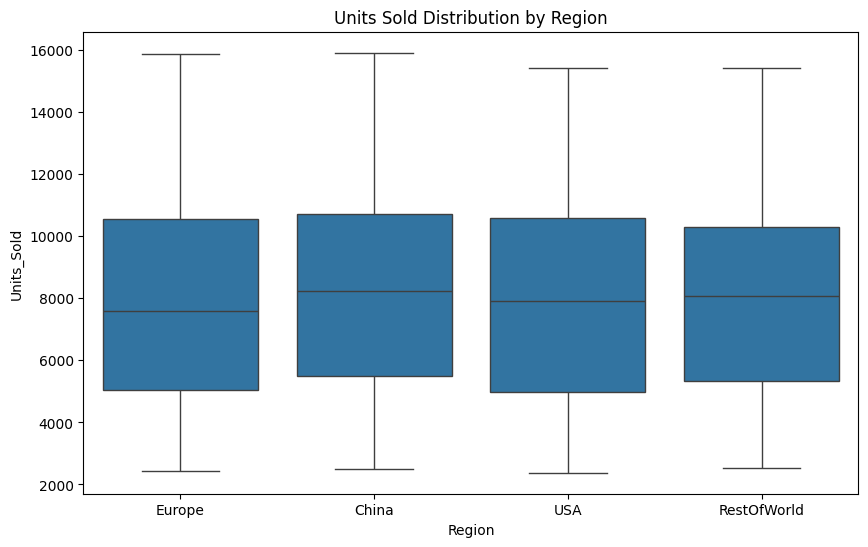

In [83]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Region", y="Units_Sold", data=df)
plt.title("Units Sold Distribution by Region")
plt.show()

<Axes: xlabel='Units_Sold', ylabel='Revenue_EUR'>

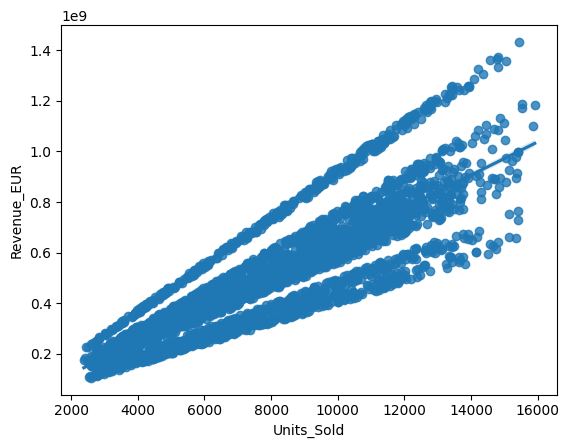

In [89]:
df[['Revenue_EUR','Units_Sold','Avg_Price_EUR','Premium_Share']].corr()

sns.regplot(x="Units_Sold", y="Revenue_EUR", data=df)

# EDA Conclusions (BMW Global Sales 2018–2025)

1) Overall sales trend is upward: total units sold increase from 2,765,193 in 2018 to 3,362,777 in 2025, about 2.8% CAGR.
2) Growth is not perfectly steady: 2019 is flat (-0.19% YoY), a clear step‑up happens in 2020 (+10.03% YoY), then steady low‑single‑digit growth through 2025.
3) Seasonal pattern exists: June, March, December, and September are the highest‑volume months; January, February, August, and October are the weakest.
4) Model mix is led by SUVs and EVs: X3/X5/X7 together are ~37.6% of total units; EV models i4 + iX are ~25.5%; 3/5 Series are ~24.7%; MINI ~12.1%.
5) Regional volumes are balanced: China is the largest at ~25.5% of total units, but all regions are within ~1% of each other.
6) BEV share rises sharply from ~2.1% (2018) to ~19.4% (2025), a +17.4 percentage‑point increase.
7) BEV adoption is similar across regions; differences are marginal in this dataset.
8) Fuel price index correlates strongly with BEV share (corr ≈ 0.95), supporting the “higher fuel prices → higher BEV share” insight.
9) GDP growth shows near‑zero correlation with units sold (corr ≈ -0.015) and there are no negative GDP values in the dataset, so the “sales drop during negative GDP growth” claim is not supported here
10) Revenue and units sold are strongly correlated (corr ≈ 0.86), indicating volume is the main revenue driver in this dataset.
11) Average prices are very similar across regions (differences are small), suggesting limited price dispersion by geography.